In [1]:
 import torch

# Configure PyTorch to use the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == 'cuda':
    print("GPU Device Name:", torch.cuda.get_device_name(0))
    print("Memory Allocated:", torch.cuda.memory_allocated(0))
    print("Memory Cached:", torch.cuda.memory_reserved(0))
else:
    print("No GPU devices found. Running on CPU.")


Using device: cuda
GPU Device Name: Tesla T4
Memory Allocated: 0
Memory Cached: 0


Using device: cuda
GPU Device Name: Tesla T4
Indexing dataset... (This may take 2-5 minutes for ISIC 2024, please do not interrupt)
Successfully indexed 322498 images in 2 classes.


Epoch 1/20: 100%|██████████| 10079/10079 [15:02<00:00, 11.17it/s, acc=0.994, loss=0.00216]


Epoch 1 Summary -> Train Acc: 0.9938, Val Acc: 0.9990


Epoch 2/20: 100%|██████████| 10079/10079 [15:11<00:00, 11.05it/s, acc=0.994, loss=0.0117] 


Epoch 2 Summary -> Train Acc: 0.9939, Val Acc: 0.9990


...

Epoch 19/20: 100%|██████████| 10079/10079 [14:47<00:00, 11.36it/s, acc=0.994, loss=nan]


Epoch 19 Summary -> Train Acc: 0.9939, Val Acc: 0.9990


Epoch 20/20: 100%|██████████| 10079/10079 [14:49<00:00, 11.33it/s, acc=0.994, loss=nan]


Epoch 20 Summary -> Train Acc: 0.9939, Val Acc: 0.9990
Model and history saved to /kaggle/working/


ValueError: Input contains NaN.

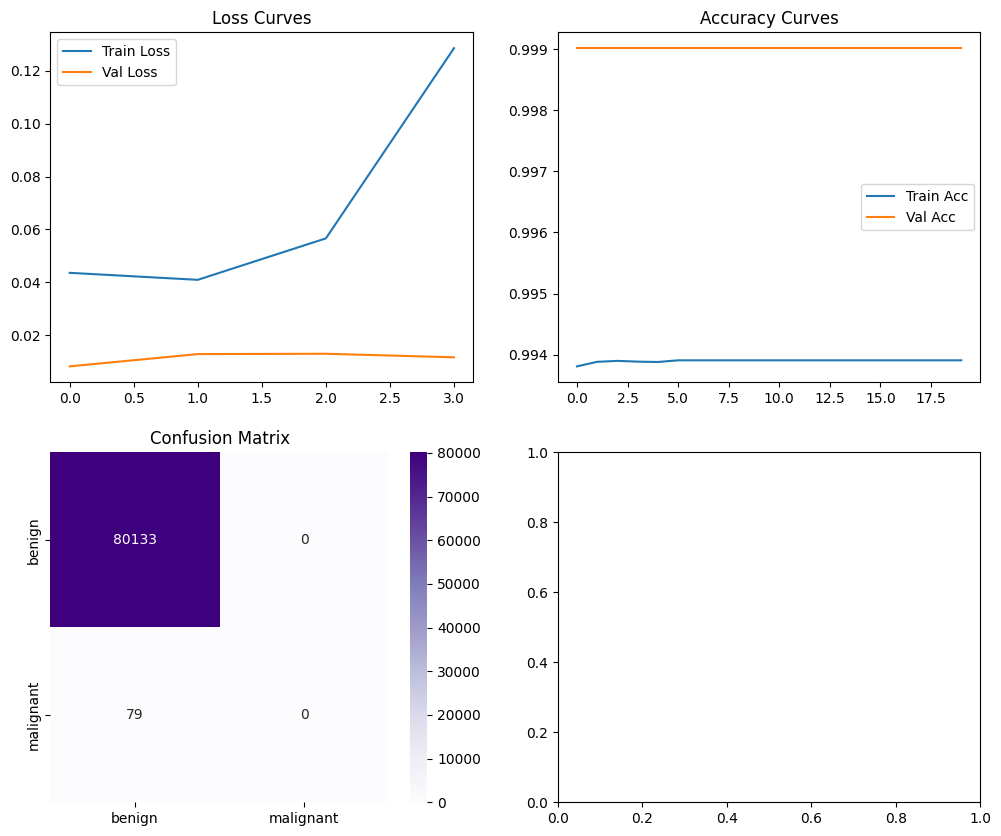

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- 1. CONFIGURATION & PATHS ---
TRAIN_DIR = "/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/train"
VAL_DIR = "/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/test"

CONFIG = {
    "BATCH_SIZE": 32,
    "EPOCHS": 20,
    "LR": 0.001,
    "DEVICE": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "NUM_WORKERS": 2,
    "MODEL_SAVE_PATH": "/kaggle/working/cnn_isic2024.pth",
    "HISTORY_SAVE_PATH": "/kaggle/working/training_history.pth"
}

print(f"Using device: {CONFIG['DEVICE']}")
if CONFIG['DEVICE'].type == 'cuda':
    print("GPU Device Name:", torch.cuda.get_device_name(0))

# --- 2. DATA TRANSFORMS ---
# Added basic augmentation to help with generalization
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# --- 3. DATASETS & LOADERS ---
print("Indexing dataset... (This may take 2-5 minutes for ISIC 2024, please do not interrupt)")

try:
    train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
    val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_transform)
    
    # Using persistent_workers=True can help speed up subsequent epochs
    train_loader = DataLoader(
        train_dataset, 
        batch_size=CONFIG["BATCH_SIZE"], 
        shuffle=True, 
        num_workers=CONFIG["NUM_WORKERS"], 
        pin_memory=True,
        persistent_workers=True 
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=CONFIG["BATCH_SIZE"], 
        shuffle=False, 
        num_workers=CONFIG["NUM_WORKERS"], 
        pin_memory=True,
        persistent_workers=True
    )

    classes = train_dataset.classes
    print(f"Successfully indexed {len(train_dataset)} images in {len(classes)} classes.")

except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Check if TRAIN_DIR and VAL_DIR paths are correct for the ISIC 2024 dataset.")

# --- 4. MODEL ARCHITECTURE ---
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Added Dropout to prevent overfitting
        self.fc_layers = nn.Sequential(
            nn.Linear(28 * 28 * 128, 256),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(256, len(classes))
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# --- 5. TRAINING INITIALIZATION ---
model = CNN().to(CONFIG["DEVICE"])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["LR"])
scaler = torch.amp.GradScaler(device='cuda') if torch.cuda.is_available() else None

# --- 6. TRAINING LOOP ---
history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

for epoch in range(CONFIG["EPOCHS"]):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['EPOCHS']}")

    for inputs, labels in pbar:
        inputs, labels = inputs.to(CONFIG["DEVICE"], non_blocking=True), labels.to(CONFIG["DEVICE"], non_blocking=True)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        if scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=loss.item(), acc=correct/total)

    # Validation
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(CONFIG["DEVICE"]), labels.to(CONFIG["DEVICE"])
            outputs = model(inputs)
            v_loss += criterion(outputs, labels).item()
            _, preds = torch.max(outputs, 1)
            v_correct += (preds == labels).sum().item()
            v_total += labels.size(0)

    history["loss"].append(running_loss/len(train_loader))
    history["accuracy"].append(correct/total)
    history["val_loss"].append(v_loss/len(val_loader))
    history["val_accuracy"].append(v_correct/v_total)
    
    print(f"Epoch {epoch+1} Summary -> Train Acc: {correct/total:.4f}, Val Acc: {v_correct/v_total:.4f}")

# --- 7. SAVE RESULTS ---
torch.save(model.state_dict(), CONFIG["MODEL_SAVE_PATH"])
torch.save(history, CONFIG["HISTORY_SAVE_PATH"])
print("Model and history saved to /kaggle/working/")

In [ ]:
# --- 8. EVALUATION & VISUALIZATION ---
plt.figure(figsize=(12, 10))

# Plot Loss
plt.subplot(2, 2, 1)
plt.plot(history["loss"], label='Train Loss')
plt.plot(history["val_loss"], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

# Plot Accuracy
plt.subplot(2, 2, 2)
plt.plot(history["accuracy"], label='Train Acc')
plt.plot(history["val_accuracy"], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()

# Final Evaluation
model.eval()
y_probs, y_true = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(CONFIG["DEVICE"]), labels.to(CONFIG["DEVICE"])
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        y_probs.extend(probs)
        y_true.extend(labels.cpu().numpy())

y_true, y_probs = np.array(y_true), np.array(y_probs)
y_pred = (y_probs > 0.5).astype(int)

# Confusion Matrix
plt.subplot(2, 2, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')

# ROC Curve
plt.subplot(2, 2, 4)
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', label=f'ROC (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal ROC-AUC Score: {roc_auc:.4f}")
print(classification_report(y_true, y_pred, target_names=classes))